Using device: cpu
Test dataset size: 1280
Class mapping: {'no': 0, 'yes': 1}

Loading ResNet50...


c:\Users\mohdf\OneDrive - Singapore Institute Of Technology\Capstone\Project\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



ResNet50 - Test Results
Accuracy: 0.9992
AUC: 1.0000

Confusion Matrix:
[[640   0]
 [  1 639]]

Classification Report:
              precision    recall  f1-score   support

    No Tumor     0.9984    1.0000    0.9992       640
       Tumor     1.0000    0.9984    0.9992       640

    accuracy                         0.9992      1280
   macro avg     0.9992    0.9992    0.9992      1280
weighted avg     0.9992    0.9992    0.9992      1280


Loading StrongCNN...

StrongCNN - Test Results
Accuracy: 0.9016
AUC: 0.9625

Confusion Matrix:
[[559  81]
 [ 45 595]]

Classification Report:
              precision    recall  f1-score   support

    No Tumor     0.9255    0.8734    0.8987       640
       Tumor     0.8802    0.9297    0.9043       640

    accuracy                         0.9016      1280
   macro avg     0.9028    0.9016    0.9015      1280
weighted avg     0.9028    0.9016    0.9015      1280


SIDE-BY-SIDE COMPARISON
       Model  Accuracy       AUC
0   ResNet50  0.999219  0

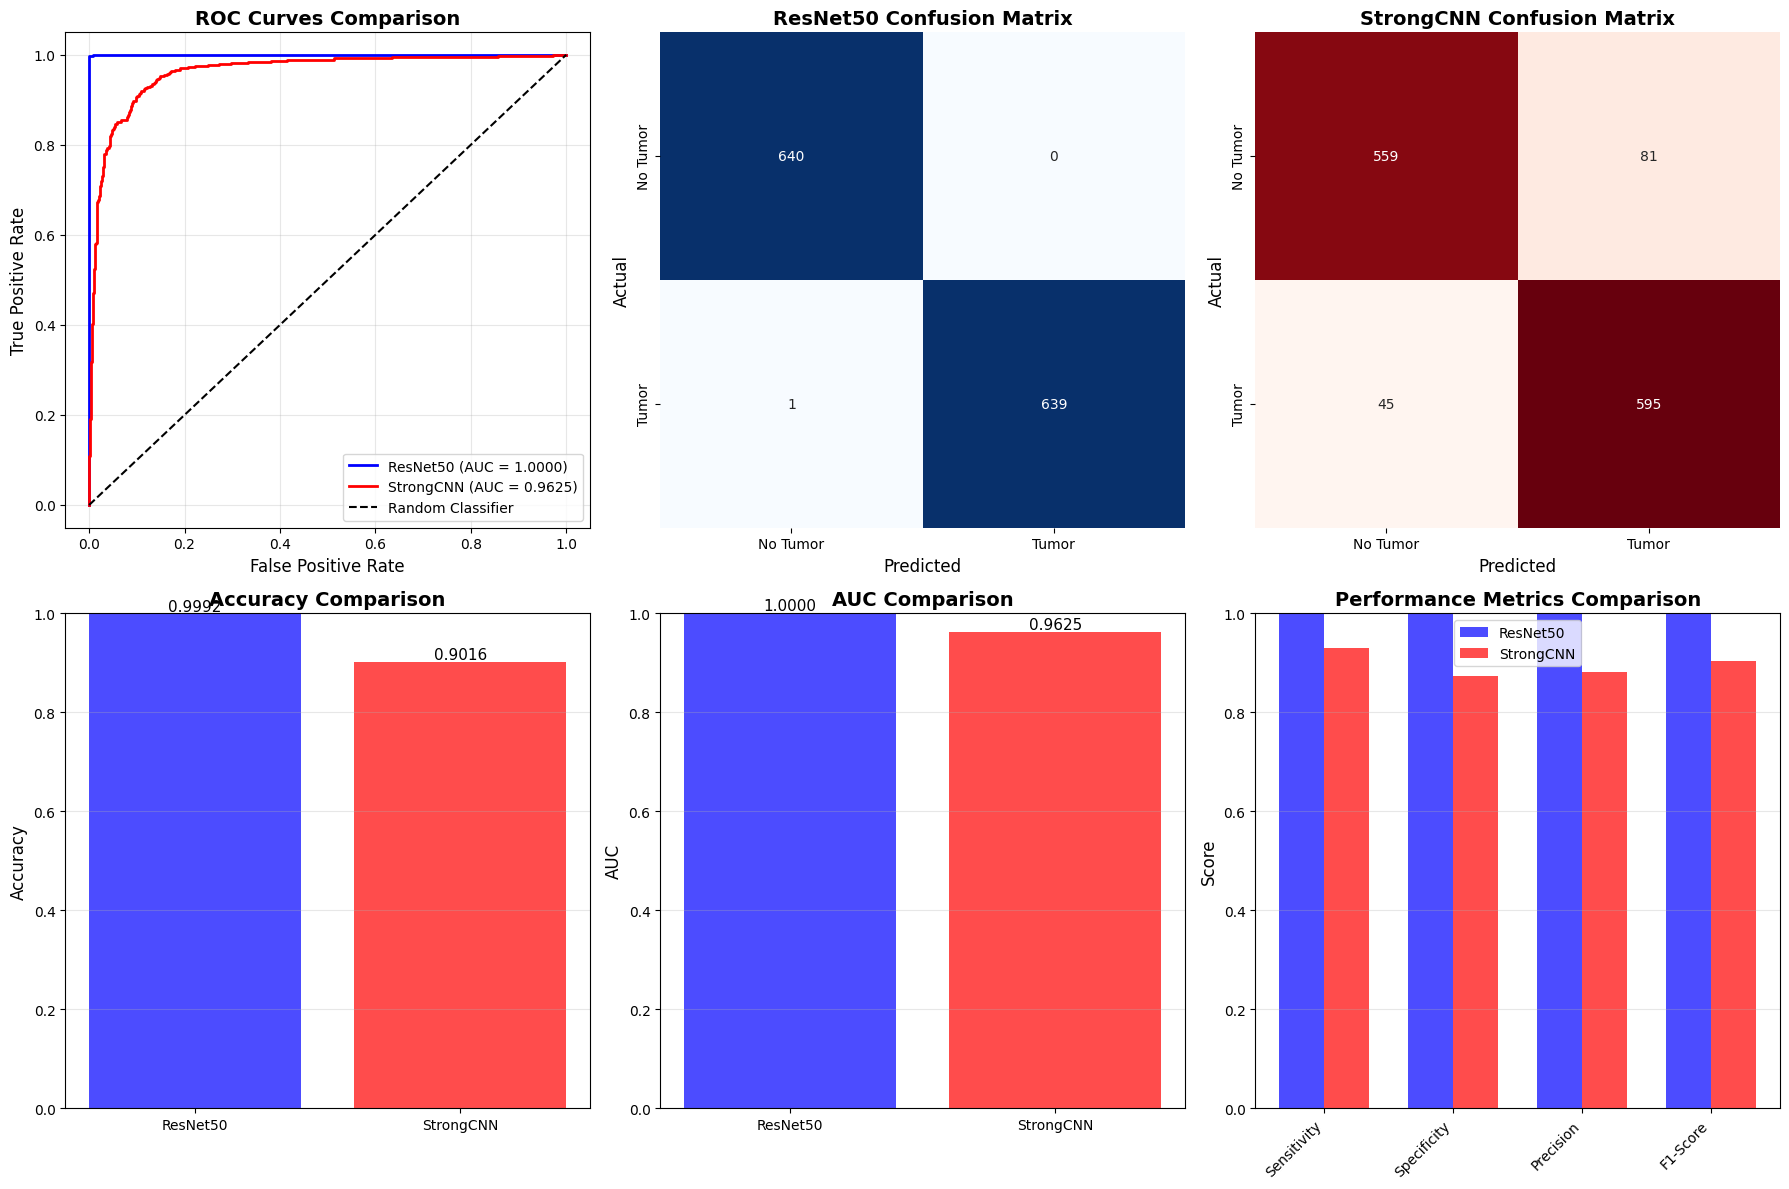


Analysis complete! Files saved:
  - model_comparison_metrics.csv
  - model_comparison_comprehensive.png
  - resnet50_test_predictions_verification.csv
  - strongcnn_test_predictions_verification.csv


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)
from pathlib import Path

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==================== Model Definitions ====================

class StrongCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.classifier(x)
        return x

# ==================== Data Loading ====================

IMG_SIZE = 224
BATCH_SIZE = 16

# ResNet50 uses ImageNet normalization
resnet_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# StrongCNN uses custom normalization (from training)
# Replace with actual mean/std if different
strongcnn_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.2793528744310471, 0.27950309053311284, 0.27967727192441916], 
                         [0.2559729772422186, 0.25598504036208913, 0.2560580670754761])
])

test_dir = "dataset_processed/test"

# Create datasets
test_dataset_resnet = datasets.ImageFolder(test_dir, transform=resnet_transform)
test_dataset_strongcnn = datasets.ImageFolder(test_dir, transform=strongcnn_transform)

# DataLoaders
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader_strongcnn = DataLoader(test_dataset_strongcnn, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Test dataset size: {len(test_dataset_resnet)}")
print(f"Class mapping: {test_dataset_resnet.class_to_idx}")

# ==================== Evaluation Function ====================

def evaluate_model(model, loader, model_name, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)[:, 1]  # Probability for class 1 (yes/tumor)
            preds = outputs.argmax(dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    # Convert to numpy arrays
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    auc_score = roc_auc_score(all_labels, all_probs)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=['No Tumor', 'Tumor'], digits=4)
    
    # ROC curve data
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - Test Results")
    print(f"{'='*60}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC: {auc_score:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    print(f"\nClassification Report:")
    print(report)
    
    return {
        'model_name': model_name,
        'labels': all_labels,
        'preds': all_preds,
        'probs': all_probs,
        'accuracy': accuracy,
        'auc': auc_score,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc,
        'report': report
    }

# ==================== Load and Evaluate ResNet50 ====================

print("\n" + "="*60)
print("Loading ResNet50...")
print("="*60)

from torchvision import models
resnet50 = models.resnet50(weights=False)
num_features = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_features, 2)
resnet50 = resnet50.to(device)

# Load checkpoint
resnet50_checkpoint = torch.load("resnet50_best.pth", map_location=device)
resnet50.load_state_dict(resnet50_checkpoint)

resnet50_results = evaluate_model(resnet50, test_loader_resnet, "ResNet50", device)

# ==================== Load and Evaluate StrongCNN ====================

print("\n" + "="*60)
print("Loading StrongCNN...")
print("="*60)

strongcnn = StrongCNN(num_classes=2).to(device)

# Load checkpoint
strongcnn_checkpoint = torch.load("strongcnn_best.pth", map_location=device)
strongcnn.load_state_dict(strongcnn_checkpoint['model_state'])

strongcnn_results = evaluate_model(strongcnn, test_loader_strongcnn, "StrongCNN", device)

# ==================== Side-by-Side Comparison ====================

print("\n" + "="*60)
print("SIDE-BY-SIDE COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['ResNet50', 'StrongCNN'],
    'Accuracy': [resnet50_results['accuracy'], strongcnn_results['accuracy']],
    'AUC': [resnet50_results['auc'], strongcnn_results['auc']]
})
print(comparison_df)

# Save comparison
comparison_df.to_csv('model_comparison_metrics.csv', index=False)

# ==================== Visualization ====================

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))

# 1. ROC Curves Comparison
ax1 = plt.subplot(2, 3, 1)
ax1.plot(resnet50_results['fpr'], resnet50_results['tpr'], 
         label=f"ResNet50 (AUC = {resnet50_results['roc_auc']:.4f})", 
         color='blue', lw=2)
ax1.plot(strongcnn_results['fpr'], strongcnn_results['tpr'], 
         label=f"StrongCNN (AUC = {strongcnn_results['roc_auc']:.4f})", 
         color='red', lw=2)
ax1.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. ResNet50 Confusion Matrix
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(resnet50_results['confusion_matrix'], annot=True, fmt='d', 
            cmap='Blues', cbar=False, ax=ax2,
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'])
ax2.set_title('ResNet50 Confusion Matrix', fontsize=14, fontweight='bold')
ax2.set_ylabel('Actual', fontsize=12)
ax2.set_xlabel('Predicted', fontsize=12)

# 3. StrongCNN Confusion Matrix
ax3 = plt.subplot(2, 3, 3)
sns.heatmap(strongcnn_results['confusion_matrix'], annot=True, fmt='d', 
            cmap='Reds', cbar=False, ax=ax3,
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'])
ax3.set_title('StrongCNN Confusion Matrix', fontsize=14, fontweight='bold')
ax3.set_ylabel('Actual', fontsize=12)
ax3.set_xlabel('Predicted', fontsize=12)

# 4. Accuracy Comparison Bar Chart
ax4 = plt.subplot(2, 3, 4)
models = ['ResNet50', 'StrongCNN']
accuracies = [resnet50_results['accuracy'], strongcnn_results['accuracy']]
bars = ax4.bar(models, accuracies, color=['blue', 'red'], alpha=0.7)
ax4.set_ylabel('Accuracy', fontsize=12)
ax4.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax4.set_ylim([0, 1.0])
ax4.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=11)

# 5. AUC Comparison Bar Chart
ax5 = plt.subplot(2, 3, 5)
aucs = [resnet50_results['auc'], strongcnn_results['auc']]
bars = ax5.bar(models, aucs, color=['blue', 'red'], alpha=0.7)
ax5.set_ylabel('AUC', fontsize=12)
ax5.set_title('AUC Comparison', fontsize=14, fontweight='bold')
ax5.set_ylim([0, 1.0])
ax5.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=11)

# 6. Confusion Matrix Metrics Breakdown
ax6 = plt.subplot(2, 3, 6)
# Calculate metrics for both models
def calc_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    return sensitivity, specificity, precision, f1

resnet_metrics = calc_metrics(resnet50_results['confusion_matrix'])
strongcnn_metrics = calc_metrics(strongcnn_results['confusion_matrix'])

x = np.arange(4)
width = 0.35
metrics_labels = ['Sensitivity', 'Specificity', 'Precision', 'F1-Score']

bars1 = ax6.bar(x - width/2, resnet_metrics, width, label='ResNet50', color='blue', alpha=0.7)
bars2 = ax6.bar(x + width/2, strongcnn_metrics, width, label='StrongCNN', color='red', alpha=0.7)

ax6.set_ylabel('Score', fontsize=12)
ax6.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(metrics_labels, rotation=45, ha='right')
ax6.legend()
ax6.set_ylim([0, 1.0])
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== Save Detailed Results ====================

# Save predictions for both models
resnet50_preds_df = pd.DataFrame({
    'label': resnet50_results['labels'],
    'pred_class': resnet50_results['preds'],
    'pred_prob': resnet50_results['probs']
})
resnet50_preds_df.to_csv('resnet50_test_predictions_verification.csv', index=False)

strongcnn_preds_df = pd.DataFrame({
    'label': strongcnn_results['labels'],
    'pred_class': strongcnn_results['preds'],
    'pred_prob': strongcnn_results['probs']
})
strongcnn_preds_df.to_csv('strongcnn_test_predictions_verification.csv', index=False)

print("\n" + "="*60)
print("Analysis complete! Files saved:")
print("  - model_comparison_metrics.csv")
print("  - model_comparison_comprehensive.png")
print("  - resnet50_test_predictions_verification.csv")
print("  - strongcnn_test_predictions_verification.csv")
print("="*60)